# The terminal viewer, part two: probing, cut-aways, comparison and time series

Added in v16.36.0. [`32_interactive_terminal.ipynb`](32_interactive_terminal.ipynb) orbits one mesh; the viewer (`meshioplusplus tui`, `mp.tui`) now also **probes** the cell under the pointer, takes a `:` **command line** that speaks the flags of `snapshot`, **cuts the model away** along planes, draws **two meshes side by side** (or their difference) and steps through a **time series**, even one still being written. See `doc/tui.md`.

A notebook is not a terminal, so each part below replays a recorded session (the same loop, fed recorded keys and mouse reports on a screen of a stated size) and shows what it did beside what PyVista draws.

In [1]:
import json
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')
TMP = tempfile.mkdtemp()

raw = mp.read(os.path.join(os.path.dirname(os.getcwd()), 'Bunny.stl'))
bunny = mp.Mesh(raw.points, raw.cells, point_data={'height': raw.points[:, 2].copy()})

# Four steps of a travelling wave, written as a series of files.
z = raw.points[:, 2] / 100.0
steps = []
for k in range(4):
    path = os.path.join(TMP, f'wave_{k + 1}.vtu')
    mp.write(path, mp.Mesh(raw.points, raw.cells, point_data={'u': np.sin(6 * z + 1.2 * k) * (1 + 0.3 * k)}))
    steps.append(path)


def mouse(code, x, y, release=False):
    return f'\x1b[<{code};{x};{y}{"m" if release else "M"}'.encode()


def click(x, y):
    return mouse(0, x, y) + mouse(0, x, y, release=True)


def tui(mesh=None, script=b'q', **options):
    return mp.tui(mesh, replay=script, cols=100, rows=34, color_depth='truecolor', **options)

## Probing a cell

A click reads the id buffer of the frame (the input cell drawn at that pixel) and describes the cell: its block and type, its nodes, the cell data there and the point data across its nodes. `i` pins a probe; two pins show their difference. Here, one click on the body and one on the ear.

In [2]:
opts = dict(color_by='height', cmap='viridis', shading='smooth')
result = tui(bunny, click(36, 24) + b'i' + click(56, 9) + b'i', title='bunny.stl', **opts)
for line in result['probe']:
    print(line)

cell 38737  block 0 triangle #38737  nodes 24078 24066 24071
at the nodes: height 105.2..105.4 (mean 105.3)
pin A: cell 57863  height=35.14
pin B: cell 38737  height=105.3
B - A: height +70.19


## The command line

`:` opens a prompt, and a command is a `snapshot` flag without the dashes. The state is kept as flags, so a bad command is a message and changes nothing, and a **session** saved to disk is just those flags as strict JSON.

In [3]:
session = os.path.join(TMP, 'view.json')
script = b':cmap magma\r:isolines 6\r:zoom 1.4\r:clip +x 40\r:cmap nope\r'
result = tui(bunny, script, title='bunny.stl', session=session, **opts)
print('status:', result['status'])
print(open(session).read())

status:  bunny.stl  az 45  el 35  zoom 1.40  ortho  cut 1  | unknown colormap 'nope' (available: viridis, coolwarm, turbo, magma, inferno, plasma, grey, viridis_r, coolwarm_r, turbo_r, magma_r, inferno_r, plasma_r, grey_r)  | ? help  q quit
{
  "flags": [
    "--cmap=magma",
    "--color-by=height",
    "--cutaway=40,0,0,1,0,0",
    "--isolines=6",
    "--shading=smooth",
    "--zoom=1.4"
  ],
  "step": 0,
  "version": 1
}



In [4]:
# The session reopens exactly where it was left.
again = tui(bunny, b'q', session=session, **opts)
print('zoom after reopening:', again['zoom'])
try:
    open(session, 'w').write('{"version": 1, "mystery": 3}')
    tui(bunny, b'q', session=session, **opts)
except ValueError as exc:
    print('a damaged session stops the start:', exc)

zoom after reopening: 1.4
a damaged session stops the start: meshio++: session: unknown key 'mystery' (expected flags, step and version) (at byte 25)


## Cut-aways

`cutaway=` takes up to two planes, each a point and the normal of the side kept (or `"+x:0.5"`). A cut surface is hollow, so the back faces now in view are tinted: the inside reads as inside. The frame stays fitted to the whole model, so the part you keep does not change size. PyVista's `clip` is the comparison.

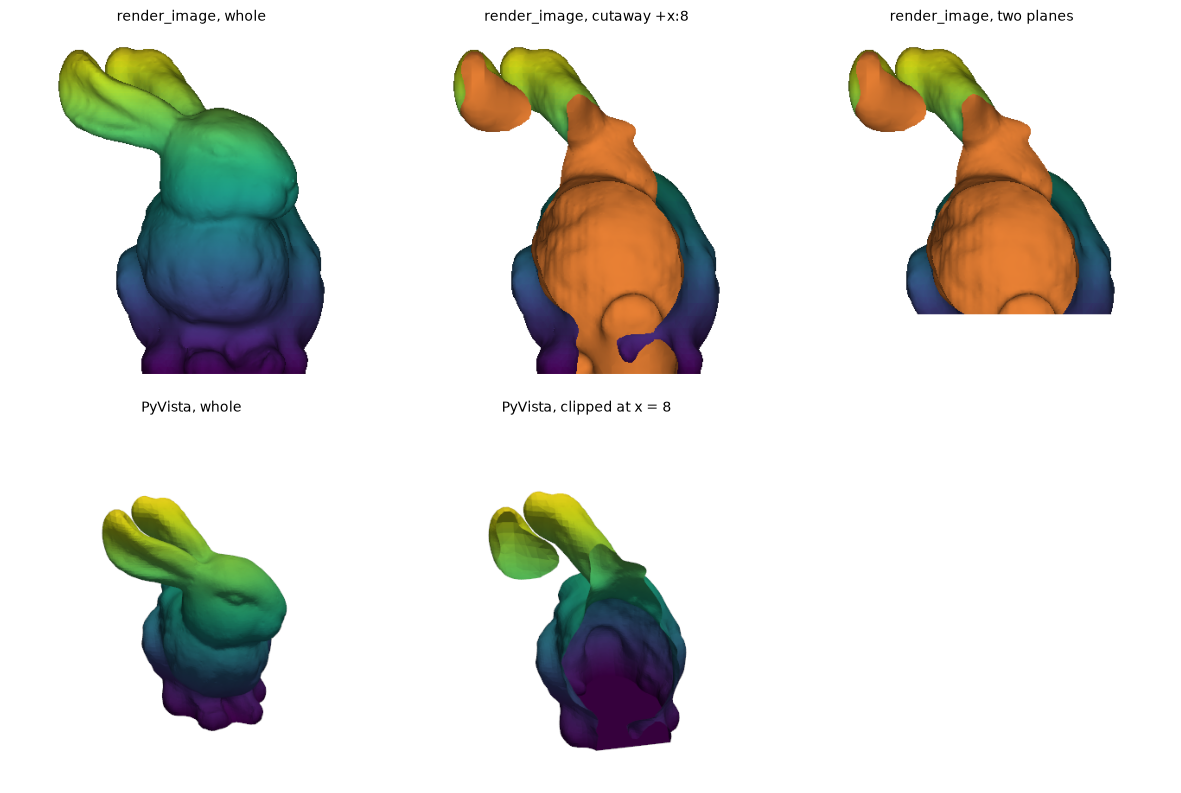

In [5]:
def to_grid(mesh):
    path = os.path.join(TMP, 'render.vtu')
    mp.write(path, mesh)
    return pv.read(path)


def pyvista_panel(ax, title, clip_x=None):
    try:
        grid = to_grid(bunny)
        if clip_x is not None:
            grid = grid.clip(normal=(1, 0, 0), origin=(clip_x, 0, 0), invert=False)
        pl = pv.Plotter(off_screen=True, window_size=(420, 420))
        pl.add_mesh(grid, scalars='height', cmap='viridis', show_scalar_bar=False)
        pl.view_vector((-1, 0.2, 0.4), viewup=(0, 0, 1))
        pl.reset_camera()
        ax.imshow(pl.screenshot(return_img=True))
        pl.close()
    except Exception as exc:  # head-less GL fallback
        print('PyVista render skipped:', exc)
        ax.scatter(bunny.points[::50, 0], bunny.points[::50, 1], s=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')


at = float(np.median(raw.points[:, 0]))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
cams = dict(view='-x', **opts)
whole = mp.render_image(bunny, 420, 420, **cams)
one = mp.render_image(bunny, 420, 420, cutaway=f'+x:{at}', **cams)
two = mp.render_image(bunny, 420, 420, cutaway=[f'+x:{at}', '+z:25'], **cams)
for ax, image, title in zip(axes[0], (whole, one, two), ('whole', f'cutaway +x:{at:.0f}', 'two planes')):
    ax.imshow(image)
    ax.set_title(f'render_image, {title}', fontsize=10)
    ax.axis('off')
pyvista_panel(axes[1, 0], 'PyVista, whole')
pyvista_panel(axes[1, 1], f'PyVista, clipped at x = {at:.0f}', clip_x=at)
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

In the viewer the same cut is `x` (once keeps the + side, twice the - side, a third time removes it), `,` and `.` slide the plane, and `:clip +x 40` types it. It is a draw-time option: the prepared scene is not touched, so sliding costs one redraw.

In [6]:
keys = tui(bunny, b'x,,', view='-x', title='bunny.stl', **{k: v for k, v in opts.items()})
print(keys['status'])

 bunny.stl  az 180  el 0  zoom 1.00  ortho  cut 1  | cut-away x >= 24.55  | ? help  q quit


## Two meshes, and their difference

`compare=` draws a second mesh beside the first under one camera and one colour range, so the same colour means the same value on both sides; `diff=True` draws `|B - A|` of the `color_by` array node by node. The two panes below are the first and last step of the series.

 wave_1.vtu  az 45  el 35  zoom 1.00  ortho  | ? help  q quit


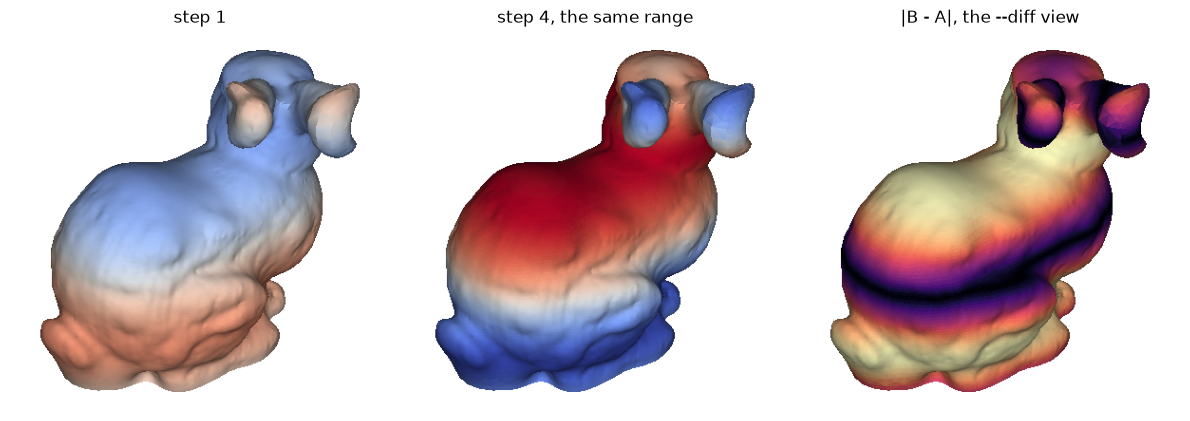

In [7]:
both = mp.tui(steps[0], compare=steps[3], replay=b'q', cols=101, rows=34, color_depth='truecolor', color_by='u', cmap='coolwarm')
print(both['status'])
a = mp.read(steps[0]); b = mp.read(steps[3])
lo = min(a.point_data['u'].min(), b.point_data['u'].min()); hi = max(a.point_data['u'].max(), b.point_data['u'].max())
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
common = dict(color_by='u', cmap='coolwarm', vmin=float(lo), vmax=float(hi), view='iso', shading='smooth')
axes[0].imshow(mp.render_image(a, 400, 400, **common)); axes[0].set_title('step 1')
axes[1].imshow(mp.render_image(b, 400, 400, **common)); axes[1].set_title('step 4, the same range')
diff = mp.Mesh(raw.points, raw.cells, point_data={'|B-A|': np.abs(b.point_data['u'] - a.point_data['u'])})
axes[2].imshow(mp.render_image(diff, 400, 400, color_by='|B-A|', cmap='magma', shading='smooth')); axes[2].set_title('|B - A|, the --diff view')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## A time series

Several files or a glob make a series, read one step at a time. `[` `]` step, `{` `}` step by ten, space plays; the colour range is fixed from the first step shown so colours do not jump (`:range auto` lets each step choose). `--follow` watches a run that is still writing and shows a new step once its file has stopped changing, keeping the last good picture while a half-written file cannot be read.

 /home/vicente/.cache/mio-scratch-t7/tmp/tmpnvu3js0v/wave_*.vtu  step 3/4  t=3  wave_3.vtu  az 45  el 35  zoom 1.00  ortho  | ? help  q quit
step shown: 3 of 4


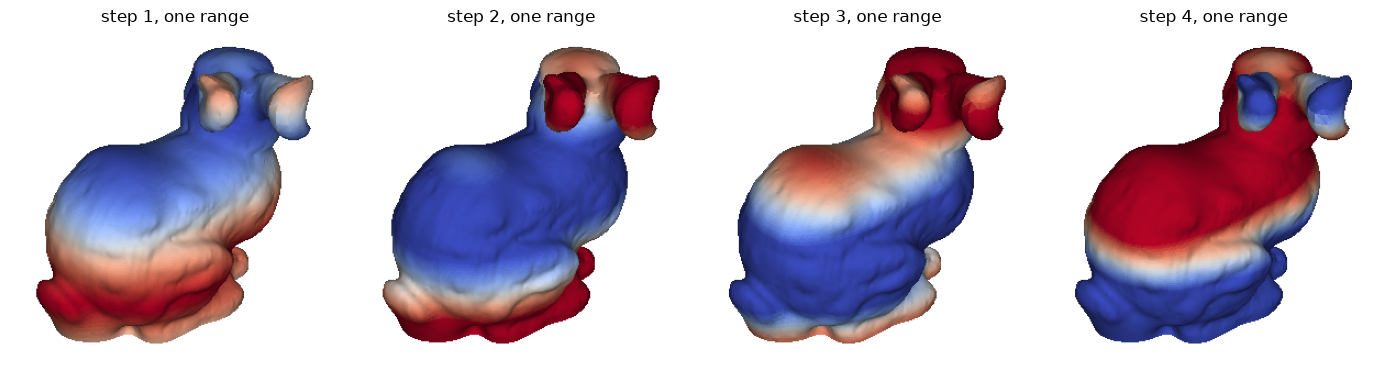

In [8]:
result = mp.tui(series=os.path.join(TMP, 'wave_*.vtu'), replay=b']]', cols=100, rows=34, color_depth='truecolor', color_by='u', cmap='coolwarm', shading='smooth')
print(result['status'])
print('step shown:', result['step'] + 1, 'of', len(steps))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for k, (ax, path) in enumerate(zip(axes, steps)):
    mesh = mp.read(path)
    ax.imshow(mp.render_image(mesh, 300, 300, color_by='u', cmap='coolwarm', vmin=-1.0, vmax=1.0, shading='smooth'))
    ax.set_title(f'step {k + 1}, one range')
    ax.axis('off')
plt.tight_layout()
plt.show()